# Parc Jean-Drapeau — BIXI Demand Anomaly Detection

Does anomalous BIXI demand at Parc Jean-Drapeau stations line up with known
island events (F1 Canadian Grand Prix, Osheaga, ÎleSoniq, Piknic Électronik)?

Pipeline: filter trips to Jean-Drapeau-area stations -> build a daily demand
series -> baseline expected demand per (month, day-of-week) from non-event
days -> robust z-score the residual -> check whether flagged anomalies line
up with the public event calendar.


In [13]:
import json
import pathlib
from collections import defaultdict

import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Config (paths match bixi_montreal.ipynb) ---
DATA_PATH  = "/Volumes/Extreme SSD/SUMO Data/station_information.json"
CSV_2025   = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2025_010203040506070809101112.csv"
CSV_2026   = "/Volumes/Extreme SSD/SUMO Data/DonneesOuvertes2026_01020304.csv"
OUTPUT_DIR = pathlib.Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


## Identify Parc Jean-Drapeau stations

Île Sainte-Hélène / Île Notre-Dame is only reachable by bike via the
Jacques-Cartier bridge path, so station-level arrivals/departures here are a
clean proxy for island-bound BIXI demand — no graph/path recomputation
needed like the Montreal-wide edge_load pipeline in `bixi_montreal.ipynb`.

The network only has **3 stations actually on the island** — there's no
dedicated "Casino de Montréal" or "Plage Jean-Drapeau" station in this BIXI
system. An earlier, looser longitude bound (`-73.515`) also pulled in two
South Shore/Longueuil stations ("Métro Longueuil-Université-de-Sherbrooke"
and "Riverside / Étienne-Truteau") that have nothing to do with the island —
tightened to `-73.528` below so only the 3 real island stations match.


In [14]:
with open(DATA_PATH) as f:
    raw = json.load(f)

stations = [s for s in raw["data"]["stations"] if s["lat"] != 0 and s["lon"] != 0]

# Bounding box around Parc Jean-Drapeau (Ile Ste-Helene / Ile Notre-Dame).
# Verified against the full station list to capture only the 3 island
# stations (Quai de la navette fluviale, Parc Jean-Drapeau, La Ronde) and
# exclude nearby South Shore/Longueuil stations.
JD_LAT_MIN, JD_LAT_MAX = 45.505, 45.525
JD_LON_MIN, JD_LON_MAX = -73.545, -73.528

jd_stations = [
    s for s in stations
    if JD_LAT_MIN <= s["lat"] <= JD_LAT_MAX and JD_LON_MIN <= s["lon"] <= JD_LON_MAX
]
jd_station_names = {s["name"] for s in jd_stations}

print(f"{len(jd_stations)} candidate Jean-Drapeau-area stations:")
for s in jd_stations:
    print(f"  {s['name']!r:45s} ({s['lat']:.5f}, {s['lon']:.5f})")


3 candidate Jean-Drapeau-area stations:
  'Quai de la navette fluviale'                 (45.51367, -73.53842)
  'Parc Jean-Drapeau (Plaine des Jeux)'         (45.51505, -73.53593)
  'La Ronde'                                    (45.52157, -73.53533)


## Map sanity check — confirm the filtered stations are actually on the island

In [15]:
m = folium.Map(location=[45.512, -73.530], zoom_start=13, tiles="CartoDB positron")

for s in stations:
    on_island = s["name"] in jd_station_names
    folium.CircleMarker(
        location=[s["lat"], s["lon"]],
        radius=6 if on_island else 3,
        color="#e63e2a" if on_island else "#888888",
        fill=True,
        fill_color="#e63e2a" if on_island else "#888888",
        fill_opacity=0.9 if on_island else 0.4,
        weight=1.5,
        tooltip=s["name"],
    ).add_to(m)

m


## Load trip data, filter to trips touching Jean-Drapeau stations

Only 2025 is used for the baseline model below — it's the first full BIXI
season in the dataset with a complete event calendar (F1, Osheaga, ÎleSoniq,
Piknic Électronik all happen in-season). `CSV_2026` only covers Jan–Apr,
before the 2026 season starts, so it isn't useful for this analysis yet.


In [16]:
COLS = ["STARTTIMEMS", "STARTSTATIONNAME", "ENDSTATIONNAME"]

def load_jd_trips(path, chunksize=200_000):
    kept = []
    for chunk in pd.read_csv(path, usecols=COLS, chunksize=chunksize, low_memory=False):
        chunk = chunk.dropna()
        touches_jd = (
            chunk["STARTSTATIONNAME"].isin(jd_station_names)
            | chunk["ENDSTATIONNAME"].isin(jd_station_names)
        )
        if touches_jd.any():
            kept.append(chunk[touches_jd])
    return pd.concat(kept, ignore_index=True) if kept else pd.DataFrame(columns=COLS)

print("Loading 2025 trips touching Jean-Drapeau stations...")
jd_trips = load_jd_trips(CSV_2025)
print(f"  {len(jd_trips):,} trips")

jd_trips["start_time_local"] = (
    pd.to_datetime(jd_trips["STARTTIMEMS"], unit="ms", utc=True)
    .dt.tz_convert("America/Montreal")
)
jd_trips["date"] = jd_trips["start_time_local"].dt.date
jd_trips["hour"] = jd_trips["start_time_local"].dt.hour
jd_trips["is_arrival"]   = jd_trips["ENDSTATIONNAME"].isin(jd_station_names)
jd_trips["is_departure"] = jd_trips["STARTSTATIONNAME"].isin(jd_station_names)


Loading 2025 trips touching Jean-Drapeau stations...
  23,390 trips


## Build the daily demand series (arrivals + departures at island stations)

In [17]:
full_range = pd.date_range(jd_trips["date"].min(), jd_trips["date"].max())

daily = (
    jd_trips.groupby("date")
    .agg(arrivals=("is_arrival", "sum"), departures=("is_departure", "sum"))
    .reindex(full_range.date, fill_value=0)
)
daily.index = pd.to_datetime(daily.index)
daily["total"]  = daily["arrivals"] + daily["departures"]
daily["dow"]    = daily.index.dayofweek   # 0 = Monday
daily["month"]  = daily.index.month

daily.to_pickle(OUTPUT_DIR / "jean_drapeau_daily.pkl")
daily.tail()


,arrivals,departures,total,dow,month
date,,,,,
2025-11-21,2,1,3,4,11
2025-11-22,9,13,22,5,11
2025-11-23,2,6,8,6,11
2025-11-24,6,8,14,0,11
2025-11-25,1,0,1,1,11


## Montreal weather (2025)

Weather is a natural confound for this anomaly detector: a heavy-rain day can
suppress demand even during a real event (risking a false negative), and a
hot sunny non-event weekend can push ordinary demand high enough to trip the
z-score threshold (a false positive). Daily mean/min/max temperature and
precipitation come from [Open-Meteo's historical archive API](https://open-meteo.com/en/docs/historical-weather-api)
(free, no key required) for a point on Île Notre-Dame/Île Ste-Hélène, over
the exact date range of `daily` (2025-04-13 to 2025-11-25). Cached to disk
after the first fetch so re-running the notebook doesn't hit the API again.

In [18]:
import requests

WEATHER_CACHE = OUTPUT_DIR / "jean_drapeau_weather_2025.csv"
JD_WEATHER_LAT, JD_WEATHER_LON = 45.512, -73.530

if WEATHER_CACHE.exists():
    weather = pd.read_csv(WEATHER_CACHE, parse_dates=["date"]).set_index("date")
else:
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": JD_WEATHER_LAT,
            "longitude": JD_WEATHER_LON,
            "start_date": daily.index.min().date().isoformat(),
            "end_date": daily.index.max().date().isoformat(),
            "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum",
            "timezone": "America/Montreal",
        },
        timeout=30,
    )
    resp.raise_for_status()
    payload = resp.json()["daily"]
    weather = pd.DataFrame({
        "date":      pd.to_datetime(payload["time"]),
        "temp_max":  payload["temperature_2m_max"],
        "temp_min":  payload["temperature_2m_min"],
        "temp_mean": payload["temperature_2m_mean"],
        "precip_mm": payload["precipitation_sum"],
    }).set_index("date")
    weather.to_csv(WEATHER_CACHE)

daily = daily.join(weather)
print(f"{weather['precip_mm'].gt(0).sum()} wet days, "
      f"mean temp range {weather['temp_mean'].min():.1f}–{weather['temp_mean'].max():.1f}°C")
daily[["temp_mean", "precip_mm"]].describe()

119 wet days, mean temp range -3.0–29.5°C


,temp_mean,precip_mm
count,227.000000,227.000000
mean,15.339207,2.756828
std,7.607344,5.405101
min,-3.000000,0.000000
25%,9.550000,0.000000
50%,17.100000,0.100000
75%,20.800000,2.400000
max,29.500000,37.600000


## Event calendar (2025)

Two different kinds of "event" here, deliberately kept separate:

- **Big one-off festivals** (F1 Canadian Grand Prix, Osheaga, ÎleSoniq) — rare,
  irregular, exactly the kind of thing anomaly detection should catch. These
  are excluded from the baseline pool and are what precision/recall is scored
  against below.
- **Piknic Électronik** — happens *every single Sunday* all season. That's
  not an anomaly, it's the normal Sunday pattern for summer months. The
  first version of this notebook excluded it from the baseline pool too,
  which left zero non-event Sundays in several months to compute a Sunday
  baseline from (median of an empty set = NaN) — every Sunday, including
  real event Sundays, scored NaN and couldn't be evaluated at all. Piknic
  days are tracked separately and folded *into* the baseline instead.


In [19]:
big_events = pd.DataFrame([
    ("F1 Canadian Grand Prix", "2025-06-13", "2025-06-15"),
    ("Osheaga",                "2025-08-01", "2025-08-03"),
    ("ileSoniq",               "2025-08-09", "2025-08-10"),
], columns=["event", "start", "end"])
big_events["start"] = pd.to_datetime(big_events["start"])
big_events["end"]   = pd.to_datetime(big_events["end"])

# Piknic Electronik: every Sunday, roughly mid-May to late Sept 2025 -- verify
# exact season bounds against piknicelectronik.com/en/events. Informational
# overlay only -- NOT excluded from the baseline pool, NOT an eval label.
piknic_sundays = pd.date_range("2025-05-18", "2025-09-28", freq="W-SUN")

def expand_event_days(events_df):
    days = set()
    for _, row in events_df.iterrows():
        days.update(pd.date_range(row["start"], row["end"]).date)
    return days

big_event_day_set = expand_event_days(big_events)
daily["is_event_day"]  = daily.index.to_series().dt.date.isin(big_event_day_set)
daily["is_piknic_day"] = daily.index.isin(piknic_sundays)
print(f"{daily['is_event_day'].sum()} big-event days, {daily['is_piknic_day'].sum()} Piknic Sundays, out of {len(daily)} total days")


8 big-event days, 20 Piknic Sundays, out of 227 total days


## Baseline expected demand

Median demand per (month, day-of-week) bucket, computed over all days
**except the big one-off festivals** — Piknic Sundays stay in the pool since
they *are* the normal Sunday pattern, not something to exclude. A day-of-week/
month bucket is used instead of STL/Prophet-style seasonal decomposition
since BIXI's ~7-month season doesn't give enough yearly cycles for that to
be reliable.


In [20]:
baseline_pool = daily[~daily["is_event_day"]]

expected = baseline_pool.groupby(["month", "dow"])["total"].median().rename("expected")
mad      = (
    baseline_pool.groupby(["month", "dow"])["total"]
    .apply(lambda x: (x - x.median()).abs().median())
    .rename("mad")
)

daily = daily.join(expected, on=["month", "dow"]).join(mad, on=["month", "dow"])


## Anomaly score

Residual = actual − expected, scored as a robust (MAD-based) z-score rather
than a mean/std z-score, since the event days themselves are heavy-tailed
outliers that would otherwise inflate a standard-deviation estimate.


In [21]:
daily["residual"] = daily["total"] - daily["expected"]
# 1.4826 scales MAD to be a consistent estimator of std dev under normality
daily["robust_z"]  = daily["residual"] / (1.4826 * daily["mad"].replace(0, np.nan))
daily["is_anomaly"] = daily["robust_z"] > 3.0


## Visualize: daily demand, event windows shaded, anomalies marked

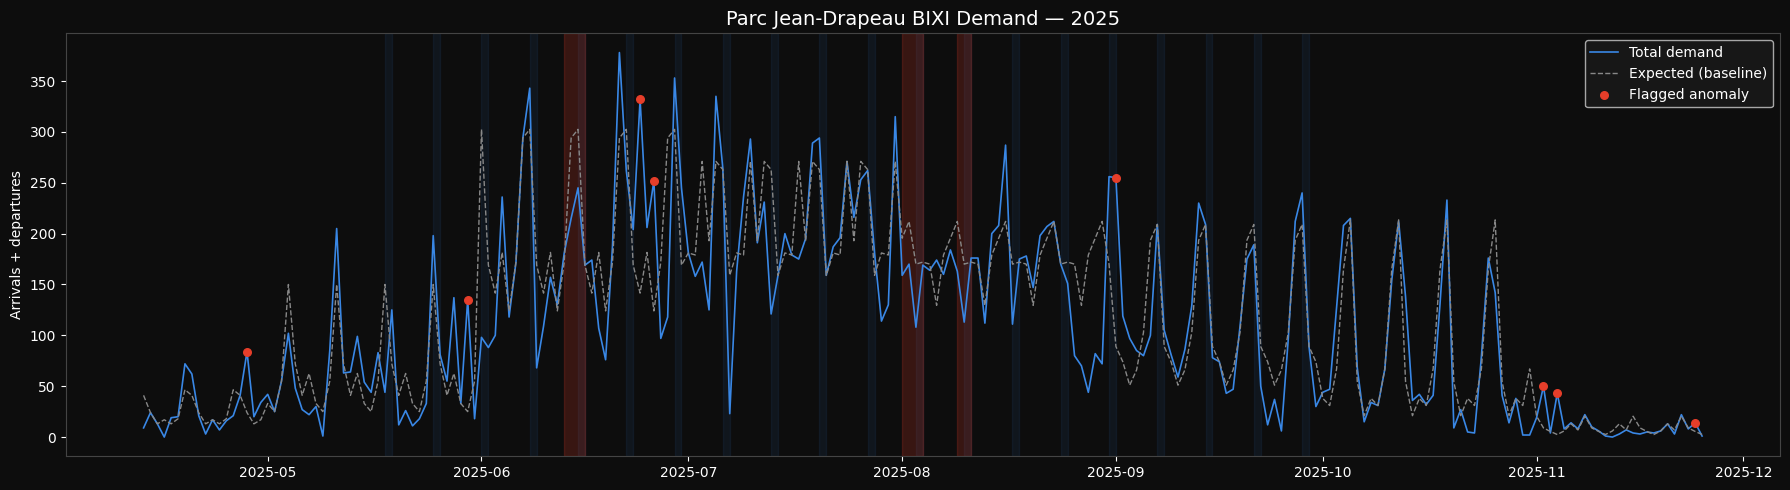

In [22]:
fig, ax = plt.subplots(figsize=(18, 5))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

ax.plot(daily.index, daily["total"], color="#3987e5", linewidth=1.2, label="Total demand")
ax.plot(daily.index, daily["expected"], color="#888888", linewidth=1, linestyle="--", label="Expected (baseline)")

for d in piknic_sundays:
    ax.axvspan(d, d + pd.Timedelta(days=1), color="#3987e5", alpha=0.08)

for _, row in big_events.iterrows():
    ax.axvspan(row["start"], row["end"] + pd.Timedelta(days=1), color="#e63e2a", alpha=0.2)

anomalies = daily[daily["is_anomaly"]]
ax.scatter(anomalies.index, anomalies["total"], color="#e63e2a", s=30, zorder=5, label="Flagged anomaly")

ax.set_title("Parc Jean-Drapeau BIXI Demand — 2025", color="white", fontsize=14)
ax.set_ylabel("Arrivals + departures", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#444444")
ax.legend(facecolor="#1a1a1a", labelcolor="white")
plt.tight_layout()
plt.show()


## Demand vs. weather

Three stacked panels sharing one time axis rather than a dual-axis overlay —
demand, temperature, and precipitation are different units and a shared
y-axis would invent a false alignment between them. Same event/anomaly
shading as above, so a flagged day's weather is readable at a glance.

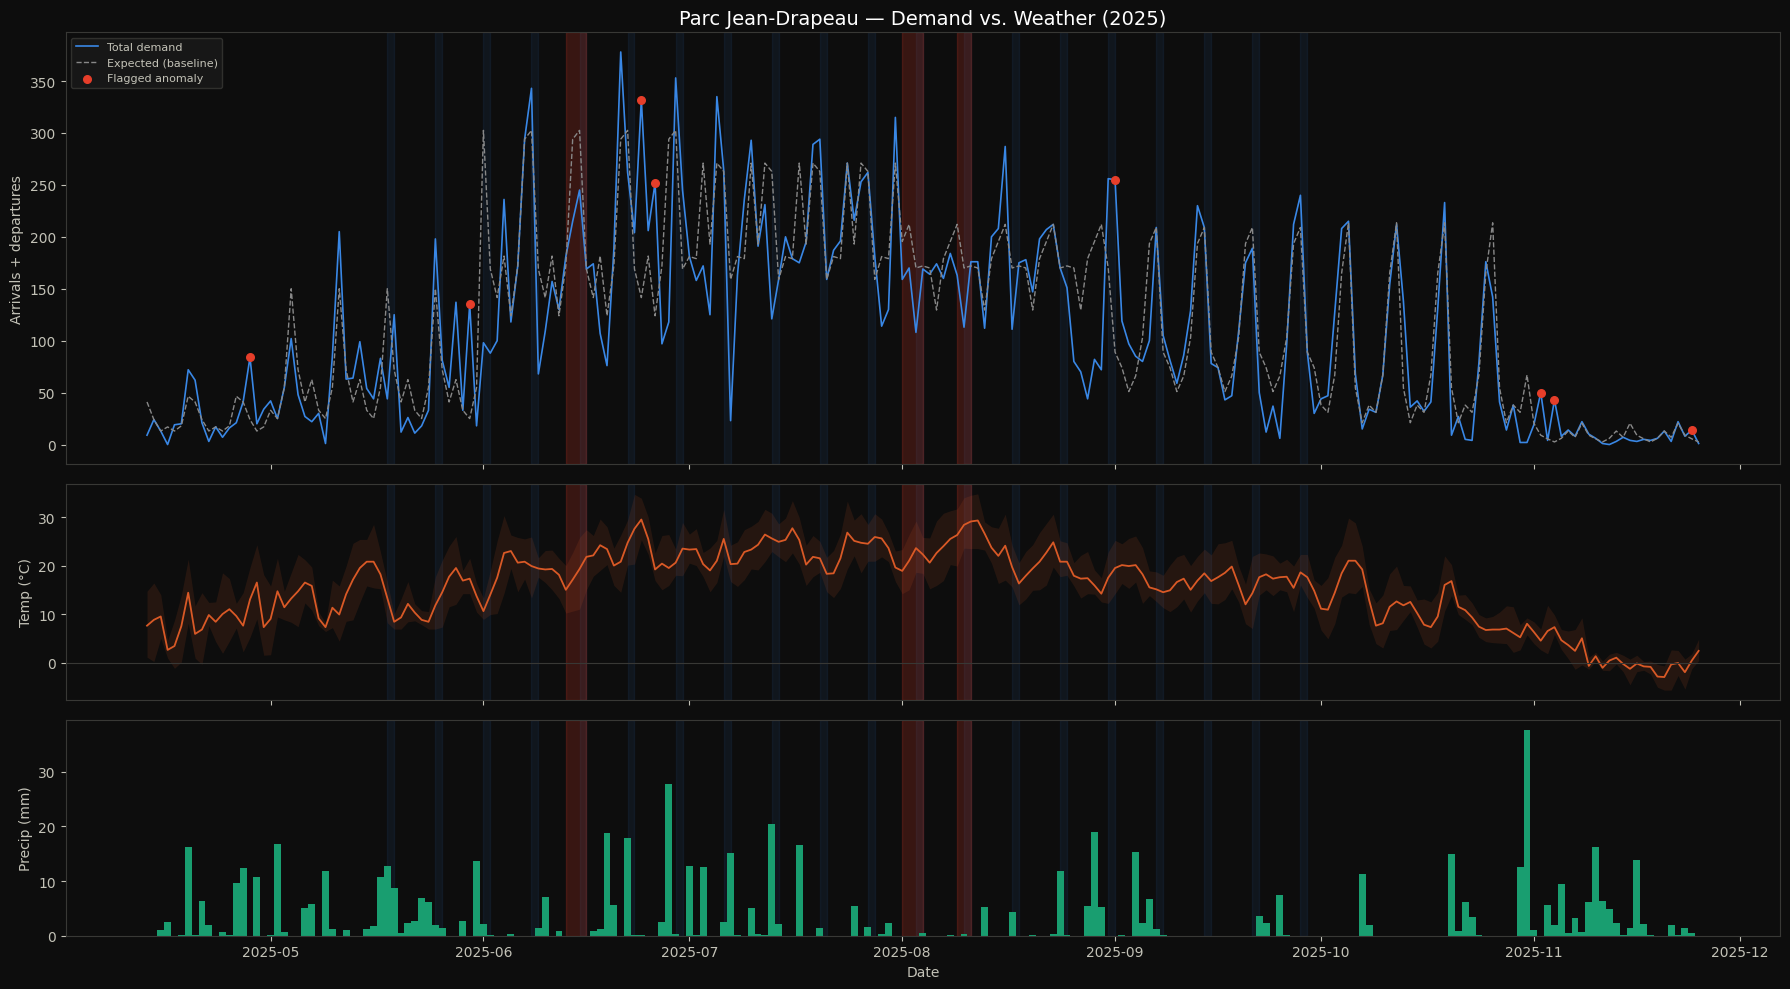

In [23]:
fig, (ax_demand, ax_temp, ax_precip) = plt.subplots(
    3, 1, figsize=(18, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]}
)
fig.patch.set_facecolor("#0d0d0d")

for ax in (ax_demand, ax_temp, ax_precip):
    ax.set_facecolor("#0d0d0d")
    ax.tick_params(colors="#c3c2b7")
    for spine in ax.spines.values():
        spine.set_color("#383835")
    for d in piknic_sundays:
        ax.axvspan(d, d + pd.Timedelta(days=1), color="#3987e5", alpha=0.08)
    for _, row in big_events.iterrows():
        ax.axvspan(row["start"], row["end"] + pd.Timedelta(days=1), color="#e63e2a", alpha=0.2)

ax_demand.plot(daily.index, daily["total"], color="#3987e5", linewidth=1.2, label="Total demand")
ax_demand.plot(daily.index, daily["expected"], color="#888888", linewidth=1, linestyle="--", label="Expected (baseline)")
anomalies = daily[daily["is_anomaly"]]
ax_demand.scatter(anomalies.index, anomalies["total"], color="#e63e2a", s=30, zorder=5, label="Flagged anomaly")
ax_demand.set_ylabel("Arrivals + departures", color="#c3c2b7")
ax_demand.set_title("Parc Jean-Drapeau — Demand vs. Weather (2025)", color="white", fontsize=14)
ax_demand.legend(facecolor="#1a1a1a", edgecolor="#383835", labelcolor="#c3c2b7", fontsize=8, loc="upper left")

ax_temp.plot(daily.index, daily["temp_mean"], color="#d95926", linewidth=1.3)
ax_temp.fill_between(daily.index, daily["temp_min"], daily["temp_max"], color="#d95926", alpha=0.12, linewidth=0)
ax_temp.axhline(0, color="#383835", linewidth=0.8)
ax_temp.set_ylabel("Temp (°C)", color="#c3c2b7")

ax_precip.bar(daily.index, daily["precip_mm"], color="#199e70", width=1.0)
ax_precip.set_ylabel("Precip (mm)", color="#c3c2b7")
ax_precip.set_xlabel("Date", color="#c3c2b7")

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "jean_drapeau_weather.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

## Evaluate: does the anomaly flag rediscover the event calendar?

Precision/recall against the event-day labels, plus explicit lists of false
positives (flagged days with no known event — check whether they cluster on
ordinary summer weekends) and false negatives (event days the model missed).


In [24]:
tp = (daily["is_anomaly"] & daily["is_event_day"]).sum()
fp = (daily["is_anomaly"] & ~daily["is_event_day"]).sum()
fn = (~daily["is_anomaly"] & daily["is_event_day"]).sum()
tn = (~daily["is_anomaly"] & ~daily["is_event_day"]).sum()

precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall    = tp / (tp + fn) if (tp + fn) else float("nan")

print(f"Precision: {precision:.2f}   Recall: {recall:.2f}")
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")

context_cols = ["total", "expected", "robust_z", "temp_mean", "precip_mm"]

print("\nFlagged anomalies NOT explained by the event calendar (check for weather confounds):")
print(daily.loc[daily["is_anomaly"] & ~daily["is_event_day"], context_cols])

print("\nEvent days the model MISSED (check whether rain suppressed demand):")
print(daily.loc[~daily["is_anomaly"] & daily["is_event_day"], context_cols])

Precision: 0.00   Recall: 0.00
TP=0  FP=8  FN=8  TN=211

Flagged anomalies NOT explained by the event calendar (check for weather confounds):
            total  expected   robust_z  temp_mean  precip_mm
date                                                        
2025-04-28     84      24.0  13.489815       13.0        0.0
2025-05-30    135      25.0   3.904947       17.3        0.0
2025-06-24    332     141.5   3.472716       29.5        0.2
2025-06-26    252     124.0   3.197586       19.2        0.0
2025-09-01    255      89.0   6.997842       19.5        0.0
2025-11-02     50       9.0   7.901177        4.5        0.0
2025-11-04     43       2.5  18.211251        7.3        1.9
2025-11-24     14       5.5   5.733171        0.4        0.5

Event days the model MISSED (check whether rain suppressed demand):
            total  expected  robust_z  temp_mean  precip_mm
date                                                       
2025-06-13    181     172.0  0.379401       15.0        0.0

## Hourly breakdown for event days

The daily total can dilute or wash out an intraday spike: a single elevated
hour spread across a 24-hour sum may not clear the day-level threshold, and a
below-typical afternoon can cancel out an above-typical evening in the same
total. Rebuild the baseline at (month, day-of-week, **hour**) granularity —
same event-day exclusion as the daily model — using hourly BIXI counts and
hourly Open-Meteo weather, then compare each event day's actual hourly shape
against its typical shape for that month/weekday/hour.

In [25]:
# --- hourly demand series (reuse jd_trips, already loaded above) ---
hourly = (
    jd_trips.groupby(["date", "hour"])
    .agg(arrivals=("is_arrival", "sum"), departures=("is_departure", "sum"))
)
full_hourly_idx = pd.MultiIndex.from_product(
    [full_range.date, range(24)], names=["date", "hour"]
)
hourly = hourly.reindex(full_hourly_idx, fill_value=0).reset_index()
hourly["date"]  = pd.to_datetime(hourly["date"])
hourly["total"] = hourly["arrivals"] + hourly["departures"]
hourly["dow"]   = hourly["date"].dt.dayofweek
hourly["month"] = hourly["date"].dt.month
hourly["is_event_day"] = hourly["date"].isin(big_event_day_set)

# --- hourly weather (Open-Meteo hourly endpoint, cached like the daily version) ---
HOURLY_WEATHER_CACHE = OUTPUT_DIR / "jean_drapeau_weather_hourly_2025.csv"

if HOURLY_WEATHER_CACHE.exists():
    hourly_weather = pd.read_csv(HOURLY_WEATHER_CACHE, parse_dates=["ts"])
else:
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": JD_WEATHER_LAT,
            "longitude": JD_WEATHER_LON,
            "start_date": daily.index.min().date().isoformat(),
            "end_date": daily.index.max().date().isoformat(),
            "hourly": "temperature_2m,precipitation",
            "timezone": "America/Montreal",
        },
        timeout=30,
    )
    resp.raise_for_status()
    payload = resp.json()["hourly"]
    hourly_weather = pd.DataFrame({
        "ts":     pd.to_datetime(payload["time"]),
        "temp":   payload["temperature_2m"],
        "precip": payload["precipitation"],
    })
    hourly_weather.to_csv(HOURLY_WEATHER_CACHE, index=False)

hourly_weather["date"] = hourly_weather["ts"].dt.normalize()
hourly_weather["hour"] = hourly_weather["ts"].dt.hour
hourly = hourly.merge(hourly_weather[["date", "hour", "temp", "precip"]], on=["date", "hour"], how="left")

# --- (month, dow, hour) baseline, excluding the same big-event days as the daily model ---
hourly_pool = hourly[~hourly["is_event_day"]]
expected_hour = hourly_pool.groupby(["month", "dow", "hour"])["total"].median().rename("expected_hour")
mad_hour = (
    hourly_pool.groupby(["month", "dow", "hour"])["total"]
    .apply(lambda x: (x - x.median()).abs().median())
    .rename("mad_hour")
)
hourly = hourly.join(expected_hour, on=["month", "dow", "hour"]).join(mad_hour, on=["month", "dow", "hour"])
hourly["resid_hour"] = hourly["total"] - hourly["expected_hour"]
hourly["z_hour"] = hourly["resid_hour"] / (1.4826 * hourly["mad_hour"].replace(0, np.nan))

hourly.to_pickle(OUTPUT_DIR / "jean_drapeau_hourly.pkl")

for _, row in big_events.iterrows():
    for d in pd.date_range(row["start"], row["end"]):
        day = hourly[hourly["date"] == d].sort_values("hour")
        ratio = day["total"].sum() / day["expected_hour"].sum()
        peak = day.loc[day["z_hour"].idxmax()]
        print(f"{row['event']:24s} {d.date()}  total {day['total'].sum():4.0f} vs typical "
              f"{day['expected_hour'].sum():6.1f}  (x{ratio:.2f})   "
              f"peak hour {int(peak['hour']):02d}:00  z={peak['z_hour']:.1f}")

F1 Canadian Grand Prix   2025-06-13  total  181 vs typical  143.5  (x1.26)   peak hour 06:00  z=8.1
F1 Canadian Grand Prix   2025-06-14  total  215 vs typical  249.5  (x0.86)   peak hour 07:00  z=3.0
F1 Canadian Grand Prix   2025-06-15  total  245 vs typical  263.0  (x0.93)   peak hour 16:00  z=10.1
Osheaga                  2025-08-01  total  159 vs typical  154.0  (x1.03)   peak hour 10:00  z=2.0
Osheaga                  2025-08-02  total  170 vs typical  150.0  (x1.13)   peak hour 18:00  z=1.3
Osheaga                  2025-08-03  total  108 vs typical  129.0  (x0.84)   peak hour 09:00  z=1.0
ileSoniq                 2025-08-09  total  163 vs typical  150.0  (x1.09)   peak hour 22:00  z=6.1
ileSoniq                 2025-08-10  total  113 vs typical  129.0  (x0.88)   peak hour 23:00  z=2.4


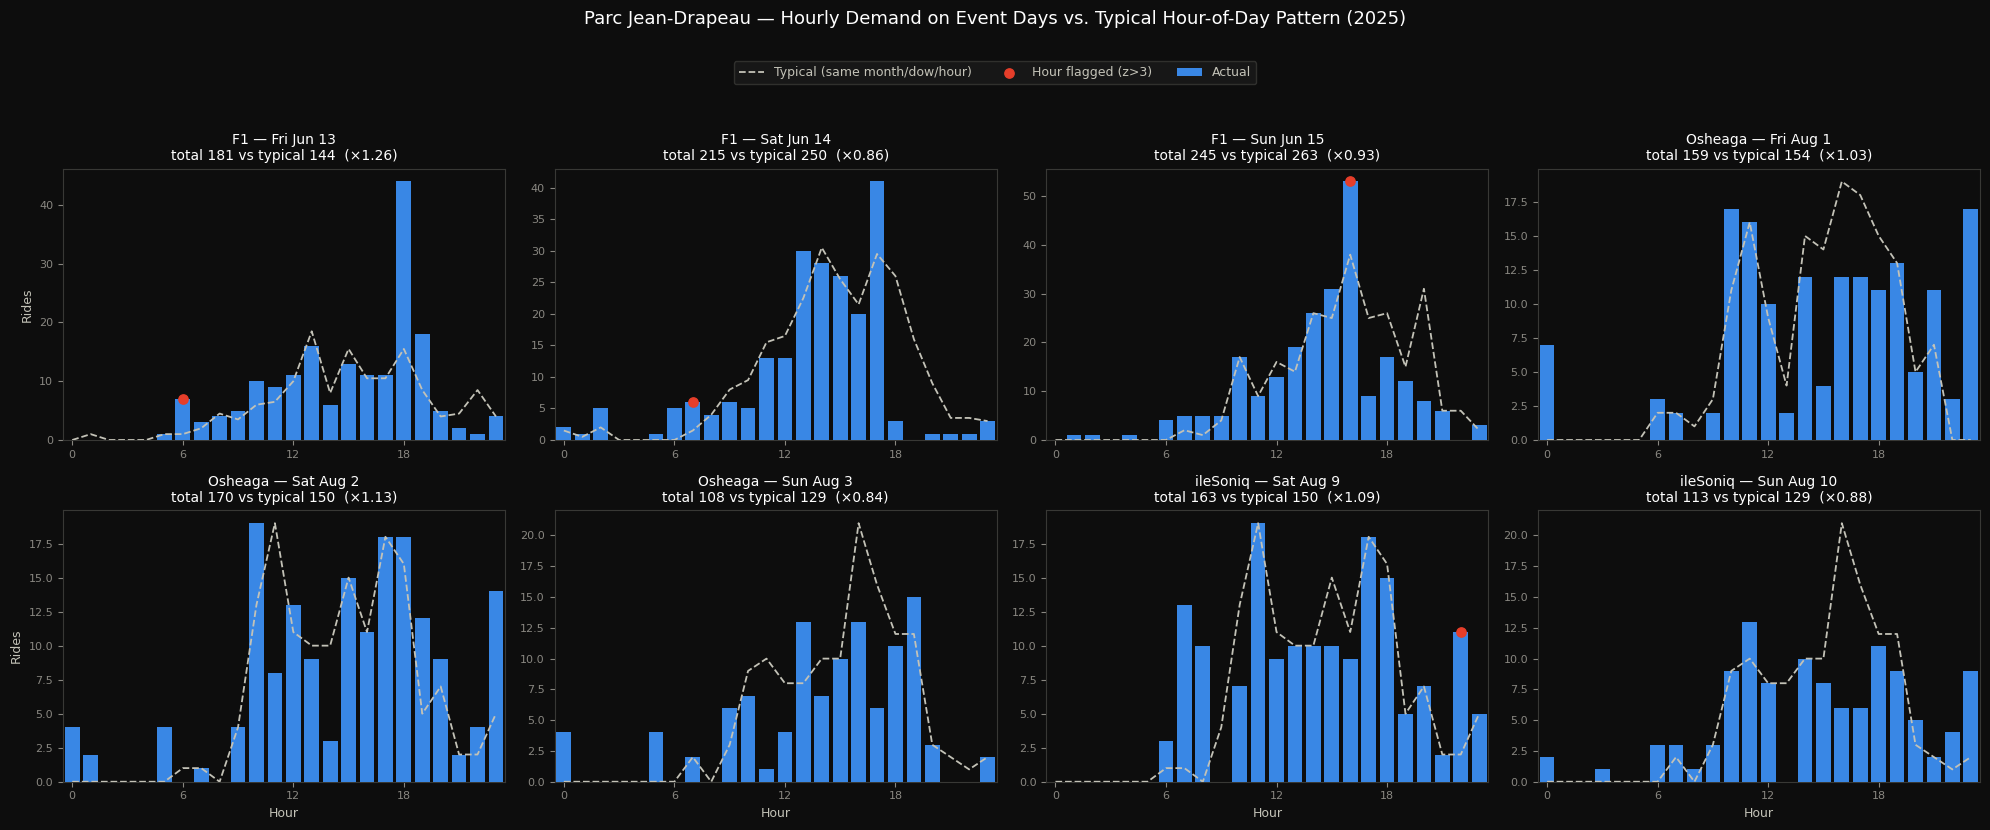

In [26]:
event_days = sorted(big_event_day_set)
event_labels = {}
for _, row in big_events.iterrows():
    for d in pd.date_range(row["start"], row["end"]):
        event_labels[d.date()] = f"{row['event'].replace('Canadian Grand Prix', '').strip()} — {d.strftime('%a %b %-d')}"

fig, axes = plt.subplots(2, 4, figsize=(20, 7.5))
fig.patch.set_facecolor("#0d0d0d")

for ax, d in zip(axes.flat, event_days):
    day = hourly[hourly["date"] == pd.Timestamp(d)].sort_values("hour")
    ax.set_facecolor("#0d0d0d")
    ax.bar(day["hour"], day["total"], color="#3987e5", width=0.8, zorder=3, label="Actual")
    ax.plot(day["hour"], day["expected_hour"], color="#c3c2b7", linewidth=1.3, linestyle="--",
            zorder=4, label="Typical (same month/dow/hour)")
    flagged = day[day["z_hour"] > 3]
    ax.scatter(flagged["hour"], flagged["total"], color="#e63e2a", s=45, zorder=5, label="Hour flagged (z>3)")
    ratio = day["total"].sum() / day["expected_hour"].sum()
    ax.set_title(f"{event_labels[d]}\ntotal {day['total'].sum():.0f} vs typical {day['expected_hour'].sum():.0f}  (×{ratio:.2f})",
                 color="white", fontsize=10)
    ax.set_xticks(range(0, 24, 6))
    ax.tick_params(colors="#898781", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("#383835")
    ax.set_xlim(-0.5, 23.5)

for ax in axes[:, 0]:
    ax.set_ylabel("Rides", color="#c3c2b7", fontsize=9)
for ax in axes[1, :]:
    ax.set_xlabel("Hour", color="#c3c2b7", fontsize=9)

handles, lbls = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="upper center", ncol=3, facecolor="#1a1a1a", edgecolor="#383835",
           labelcolor="#c3c2b7", fontsize=9, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Parc Jean-Drapeau — Hourly Demand on Event Days vs. Typical Hour-of-Day Pattern (2025)",
             color="white", fontsize=13, y=1.1)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "jean_drapeau_hourly_events.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

## Next steps

- Only 3 stations sit on the island itself, so total daily demand is a thin
  signal (order of 100/day) — check whether the false positives below are
  just noise at that volume before trusting the anomaly flag.
- Confirm exact Piknic Électronik Sunday list for the year in question
  against piknicelectronik.com/en/events — the season start/end date shifts
  year to year.
- Add hourly granularity for event days: a Friday-night Osheaga surge and a
  Sunday F1 race-day surge have different intraday shapes that a daily total
  blurs together.
- Bring in the Jacques-Cartier bridge edge-load signal from
  `bixi_montreal.ipynb` as a second, semi-independent feature (bridge
  bike-crossings vs. total island-station demand) and compare which is the
  cleaner anomaly detector.
- If false positives cluster on ordinary summer long weekends, tighten the
  baseline bucketing (e.g. a `is_long_weekend` flag) rather than raising the
  z-score threshold blindly.
